# 2. lab2. Многослойный персептрон

##Загрузка датасета (вино)

In [ ]:
df_wine = pd.read_csv('/content/drive/MyDrive/Colab_Notebooks/Wine_Quality/winequality-white.csv', sep=';')

print(f'Размер датасета: {df.shape[0]} строк, {df.shape[1]} столбцов')
print('\n--- Первые 5 строк ---')
display(df_wine.head())

print('--- Типы данных и наличие значений ---')
print(df_wine.info())
print('\n--- Базовая статистика числовых признаков ---')
display(df_wine.describe())

print("Распределение целевой переменной:")
print(df_wine['quality'].value_counts(normalize=True))

Размер датасета: 8124 строк, 23 столбцов

--- Первые 5 строк ---


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


--- Типы данных и наличие значений ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4898 entries, 0 to 4897
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         4898 non-null   float64
 1   volatile acidity      4898 non-null   float64
 2   citric acid           4898 non-null   float64
 3   residual sugar        4898 non-null   float64
 4   chlorides             4898 non-null   float64
 5   free sulfur dioxide   4898 non-null   float64
 6   total sulfur dioxide  4898 non-null   float64
 7   density               4898 non-null   float64
 8   pH                    4898 non-null   float64
 9   sulphates             4898 non-null   float64
 10  alcohol               4898 non-null   float64
 11  quality               4898 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 459.3 KB
None

--- Базовая статистика числовых признаков ---


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000
mean,6.854788,0.278241,0.334192,6.391415,0.045772,35.308085,138.360657,0.994027,3.188267,0.489847,10.514267,5.877909
std,0.843868,0.100795,0.121020,5.072058,0.021848,17.007137,42.498065,0.002991,0.151001,0.114126,1.230621,0.885639
min,3.800000,0.080000,0.000000,0.600000,0.009000,2.000000,9.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.300000,0.210000,0.270000,1.700000,0.036000,23.000000,108.000000,0.991723,3.090000,0.410000,9.500000,5.000000
50%,6.800000,0.260000,0.320000,5.200000,0.043000,34.000000,134.000000,0.993740,3.180000,0.470000,10.400000,6.000000
75%,7.300000,0.320000,0.390000,9.900000,0.050000,46.000000,167.000000,0.996100,3.280000,0.550000,11.400000,6.000000
max,14.200000,1.100000,1.660000,65.800000,0.346000,289.000000,440.000000,1.038980,3.820000,1.080000,14.200000,9.000000


Распределение целевой переменной:
quality
6    0.448755
5    0.297468
7    0.179665
8    0.035729
4    0.033279
3    0.004083
9    0.001021
Name: proportion, dtype: float64


In [ ]:
print(f'Размер до очистки: {df_wine.shape}')

# 1. Заменяем '?' на NaN во всём датасете
df_wine = df_wine.replace('?', np.nan)

# 2. Считаем пропуски до удаления
print(f'Пропусков до очистки: {df_wine.isnull().sum().sum()}')

# 3. Удаляем строки с любыми пропусками
df_clean_wine = df_wine.dropna().reset_index(drop=True)

# 4. Проверяем результат
print(f'Размер после очистки: {df_clean_wine.shape}')
print(f'Удалено строк: {len(df_wine) - len(df_clean_wine)}')

# Проверка на дубликаты
print(f"Дубликатов: {df_clean_wine.duplicated().sum()}")

# 5. Удаление дубликатов
df_clean_wine = df_clean_wine.drop_duplicates()

print(f'Всего удалено {len(df_wine) - len(df_clean_wine)} строк')
display(df_clean_wine.head())


Размер до очистки: (4898, 12)
Пропусков до очистки: 0
Размер после очистки: (4898, 12)
Удалено строк: 0
Дубликатов: 937
Всего удалено 937 строк


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
6,6.2,0.32,0.16,7.0,0.045,30.0,136.0,0.9949,3.18,0.47,9.6,6


## 2.1 Многослойный персептрон-регрессор

In [ ]:
# === 1. Подготовка данных ===
X = df_clean_wine.drop('quality', axis=1).values
y = df_clean_wine['quality'].values.astype(float).reshape(-1, 1)


scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_scaled, test_size=0.2, random_state=42
)

y_train = y_train.reshape(-1, 1)
y_test = y_test.reshape(-1, 1)

### Решение через sklearn

In [ ]:

mlp_sk = SKMLPReg(
    hidden_layer_sizes=(32, 16),
    activation='relu',
    solver='adam',
    learning_rate_init=0.01,
    max_iter=500,
    early_stopping=True,
    validation_fraction=0.1,
    random_state=42
)

print("=== Обучение MLP-регрессора (sklearn) ===")
mlp_sk.fit(X_train, y_train.ravel())

y_test_pred_sk = mlp_sk.predict(X_test).reshape(-1, 1)

print(f"\n=== Метрики на тесте (sklearn) ===")
print(f"R²: {r2_score(y_test, y_test_pred_sk):.4f}")
print(f"MSE: {mean_squared_error(y_test, y_test_pred_sk):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_test_pred_sk)):.4f}")


=== Обучение MLP-регрессора (sklearn) ===

=== Метрики на тесте (sklearn) ===
R²: 0.2986
MSE: 0.7253
RMSE: 0.8516


In [ ]:
# Точность на train и test
train_acc = (mlp_sk.predict(X_train).reshape(-1, 1) >= 0.5).astype(int)
train_acc_score = np.mean(train_acc == y_train.astype(int))

test_acc = (y_test_pred_sk >= 0.5).astype(int)
test_acc_score = np.mean(test_acc == y_test.astype(int))

print(f"Точность на TRAIN: {train_acc_score:.4f}")
print(f"Точность на TEST: {test_acc_score:.4f}")
print(f"Разница: {abs(train_acc_score - test_acc_score):.4f}")

Точность на TRAIN: 0.7437
Точность на TEST: 0.7516
Разница: 0.0079


## 2.2. Многослойный персептрон-классификатор (MLP-классификатор)


### Решение через sklearn


In [ ]:

mlp_sk = SKMLP(
    hidden_layer_sizes=(32, 16),
    activation='relu',
    solver='adam',
    max_iter=500,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1
)

mlp_sk.fit(X_train, np.argmax(y_train, axis=1))
print(f"Точность sklearn MLP: {mlp_sk.score(X_test, np.argmax(y_test, axis=1)):.4f}")

Точность sklearn MLP: 0.9973


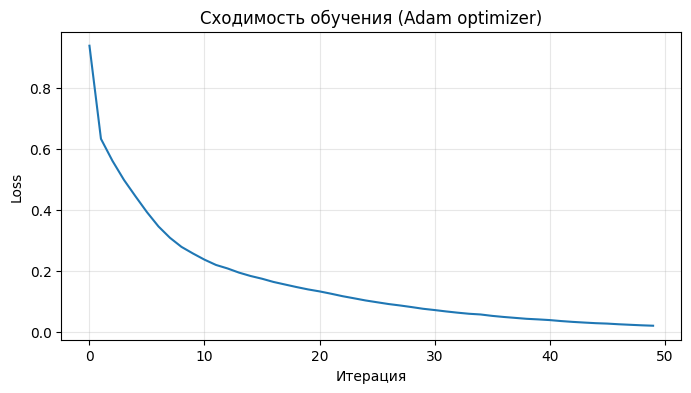

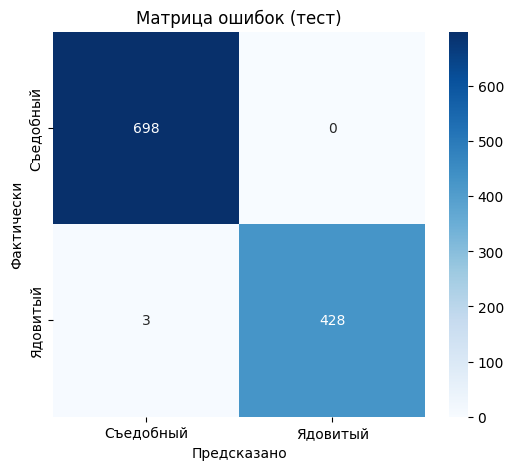


=== Classification Report (TEST) ===
              precision    recall  f1-score   support

   Съедобный       1.00      1.00      1.00       698
    Ядовитый       1.00      0.99      1.00       431

    accuracy                           1.00      1129
   macro avg       1.00      1.00      1.00      1129
weighted avg       1.00      1.00      1.00      1129



In [ ]:
# === Визуализация результатов ===

# 1. Прогнозы
y_train_pred = mlp_sk.predict(X_train)
y_test_pred = mlp_sk.predict(X_test)

# 2. График потерь (loss curve)
plt.figure(figsize=(8, 4))
plt.plot(mlp_sk.loss_curve_)
plt.xlabel('Итерация')
plt.ylabel('Loss')
plt.title('Сходимость обучения (Adam optimizer)')
plt.grid(True, alpha=0.3)
plt.show()

# 3. Матрица ошибок (тест)
cm = confusion_matrix(np.argmax(y_test, axis=1), y_test_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Съедобный', 'Ядовитый'],
            yticklabels=['Съедобный', 'Ядовитый'])
plt.xlabel('Предсказано')
plt.ylabel('Фактически')
plt.title('Матрица ошибок (тест)')
plt.show()

print("\n=== Classification Report (TEST) ===")
print(classification_report(np.argmax(y_test, axis=1), y_test_pred,
                           target_names=['Съедобный', 'Ядовитый']))